## Detrending the seasonality from the data

Detrend the data, then normalise the residual for GP.

In [1]:
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters

from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import DecomposeResult

register_matplotlib_converters()
sns.set_style("darkgrid")

In [2]:
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)

In [3]:
# Data
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
data = z500.sel(time=slice('2017.12', '2017.12', 6))

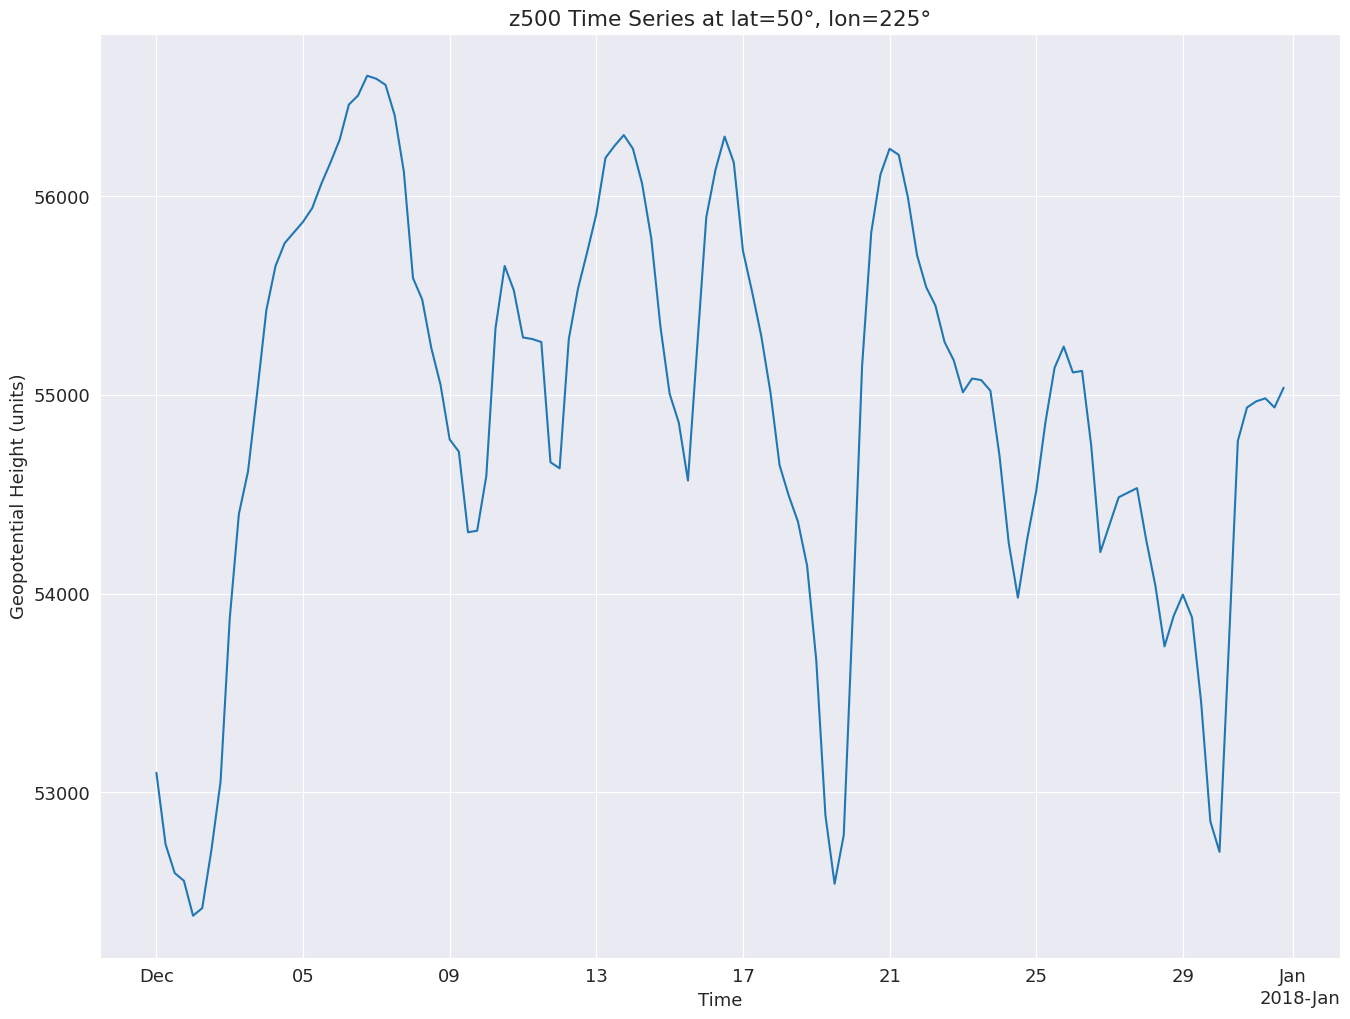

In [4]:
point_worst = data['z'].sel(lat=50, lon=225, method='nearest')
point_worst.plot.line(x='time')
plt.xlabel('Time')
plt.ylabel('Geopotential Height (units)')
plt.title('z500 Time Series at lat=50°, lon=225°')
plt.show()

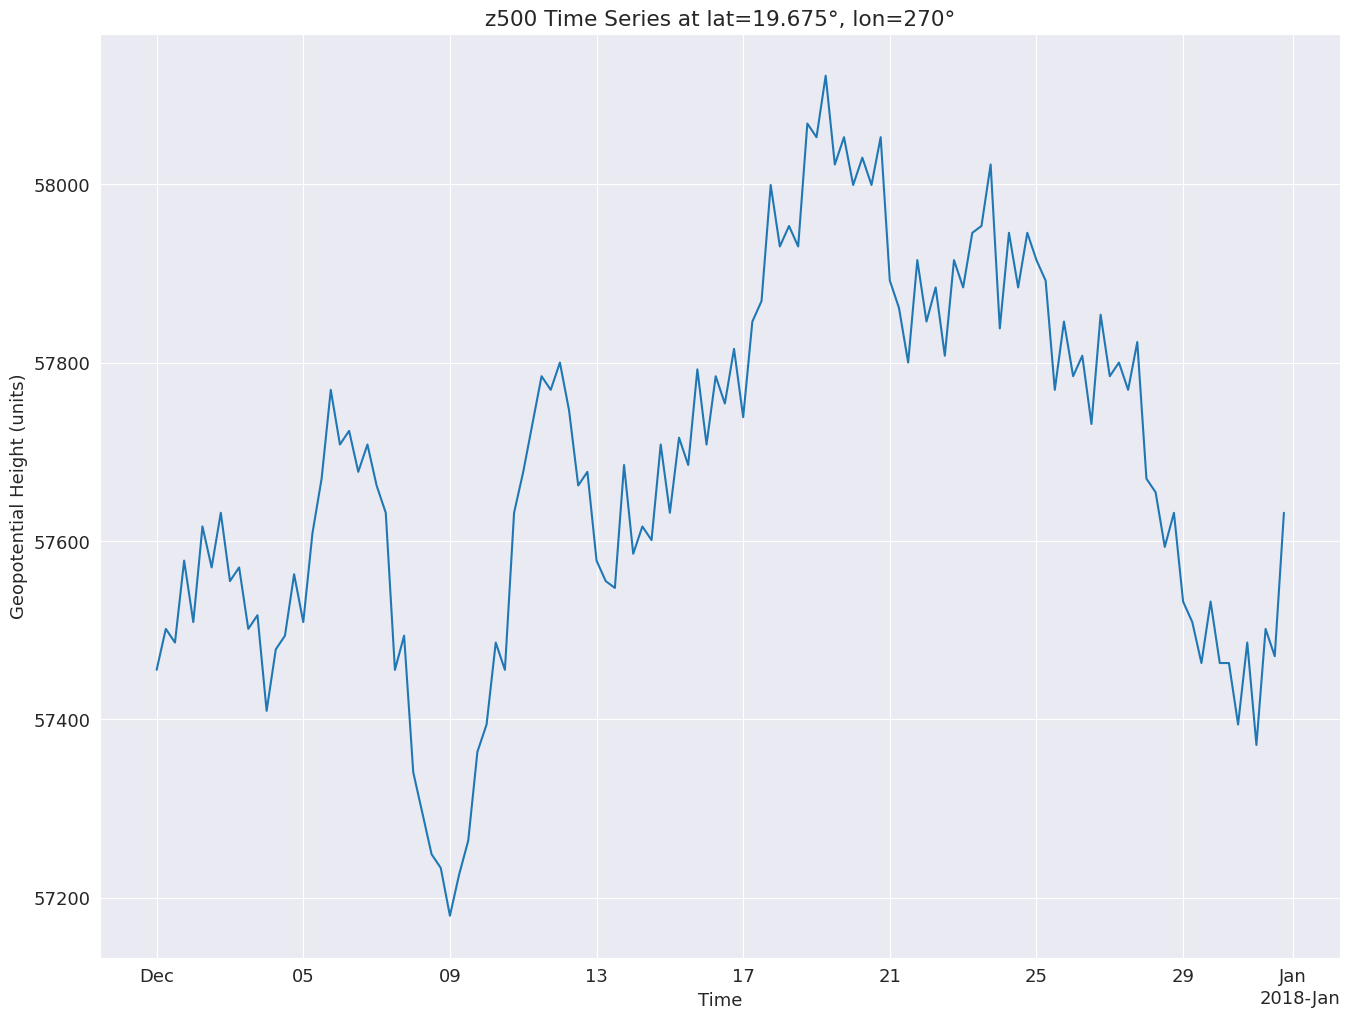

In [5]:
point_best = data['z'].sel(lat=19.6, lon=270, method='nearest')
point_best.plot.line(x='time')
plt.xlabel('Time')
plt.ylabel('Geopotential Height (units)')
plt.title('z500 Time Series at lat=19.675°, lon=270°')
plt.show()

Detrend the data at (50,225) into a trend + daily + weekly seasonal component and a residual component.

/home/syw24/miniforge3/envs/hartree/lib/python3.12/site-packages/statsmodels/tsa/stl/mstl.py:218: UserWarning: A period(s) is larger than half the length of time series. Removing these period(s).
  warnings.warn(


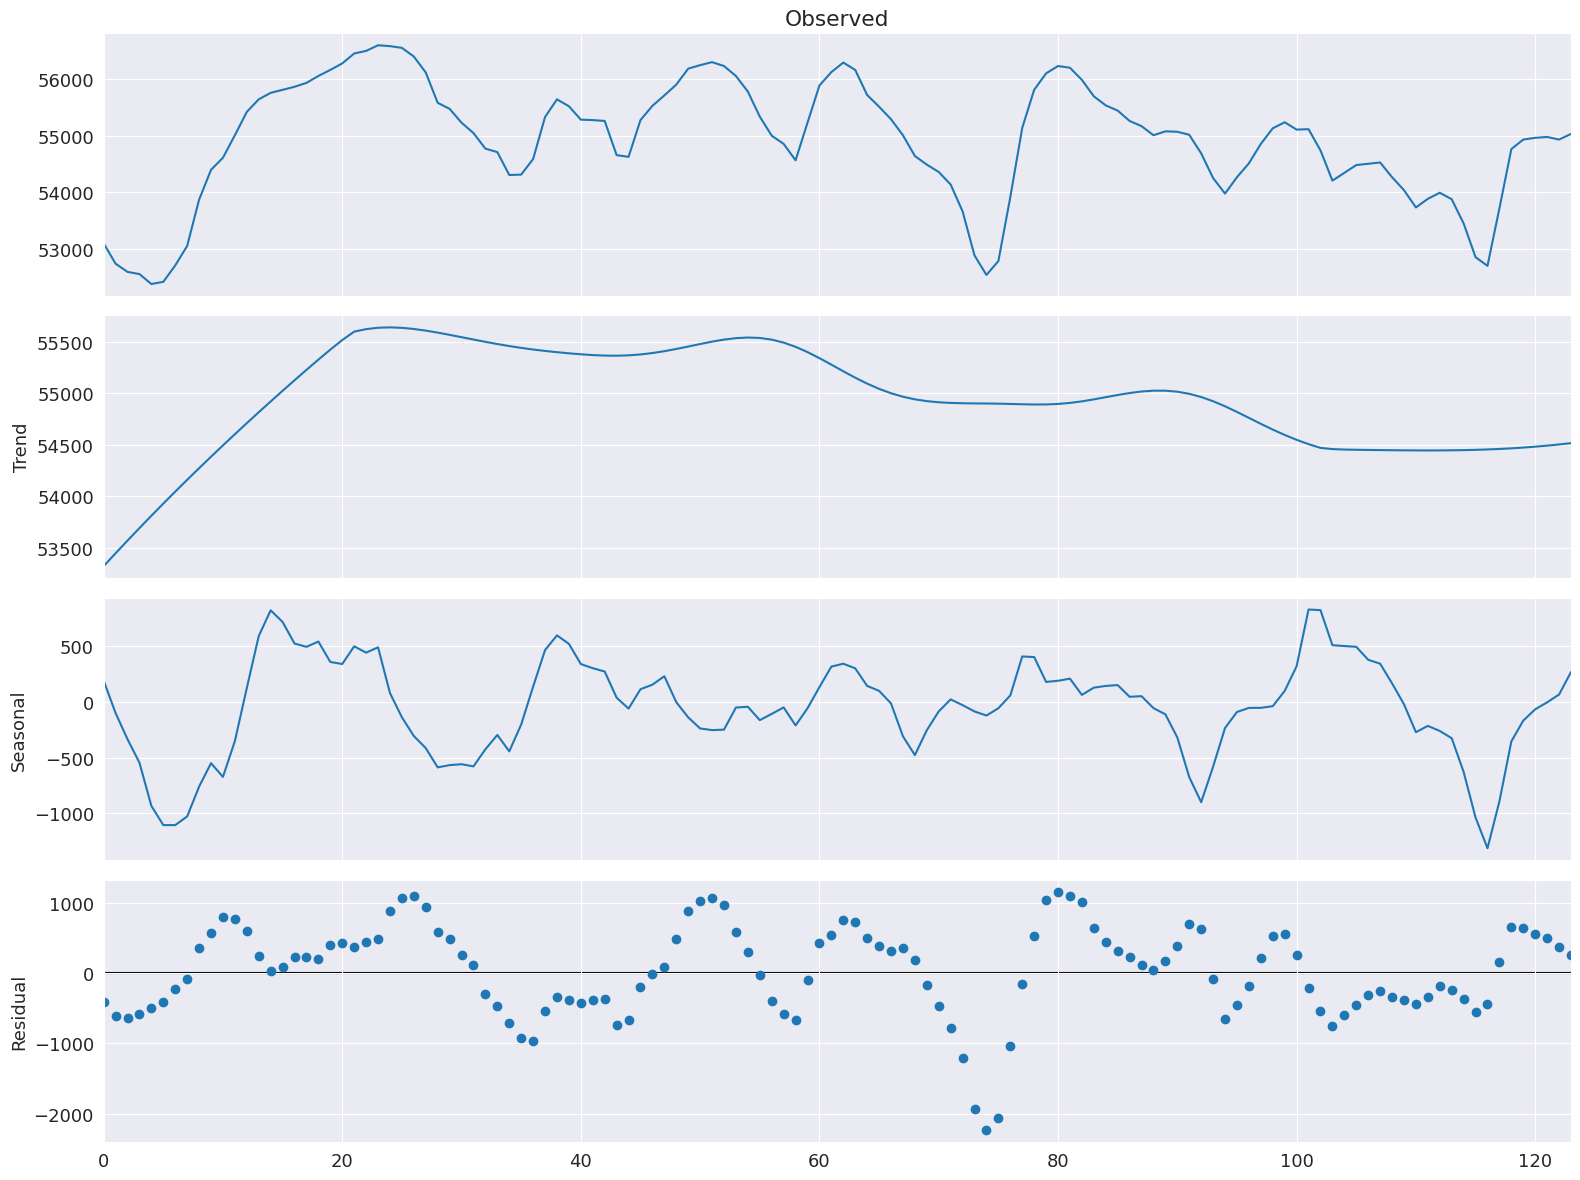

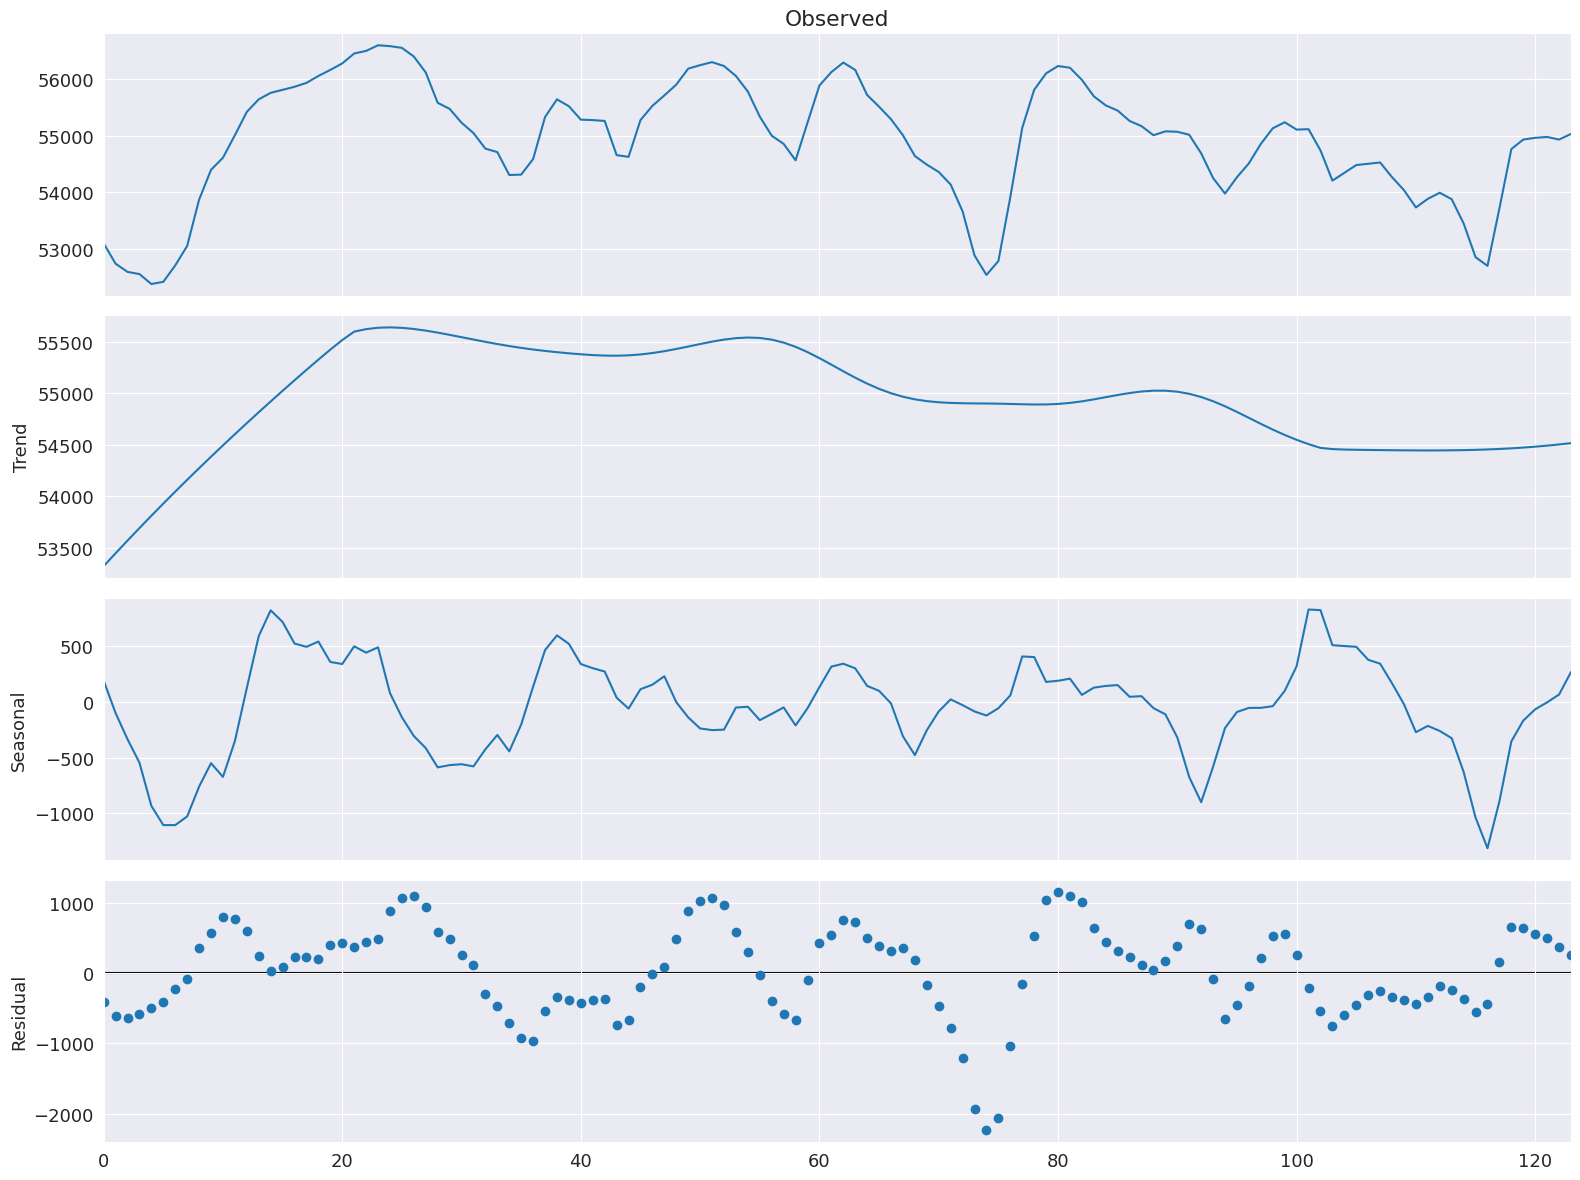

In [6]:
detrend_point_worst = MSTL(point_worst, periods=[24, 24 * 5])
residual_point_worst = detrend_point_worst.fit()
residual_point_worst.plot()

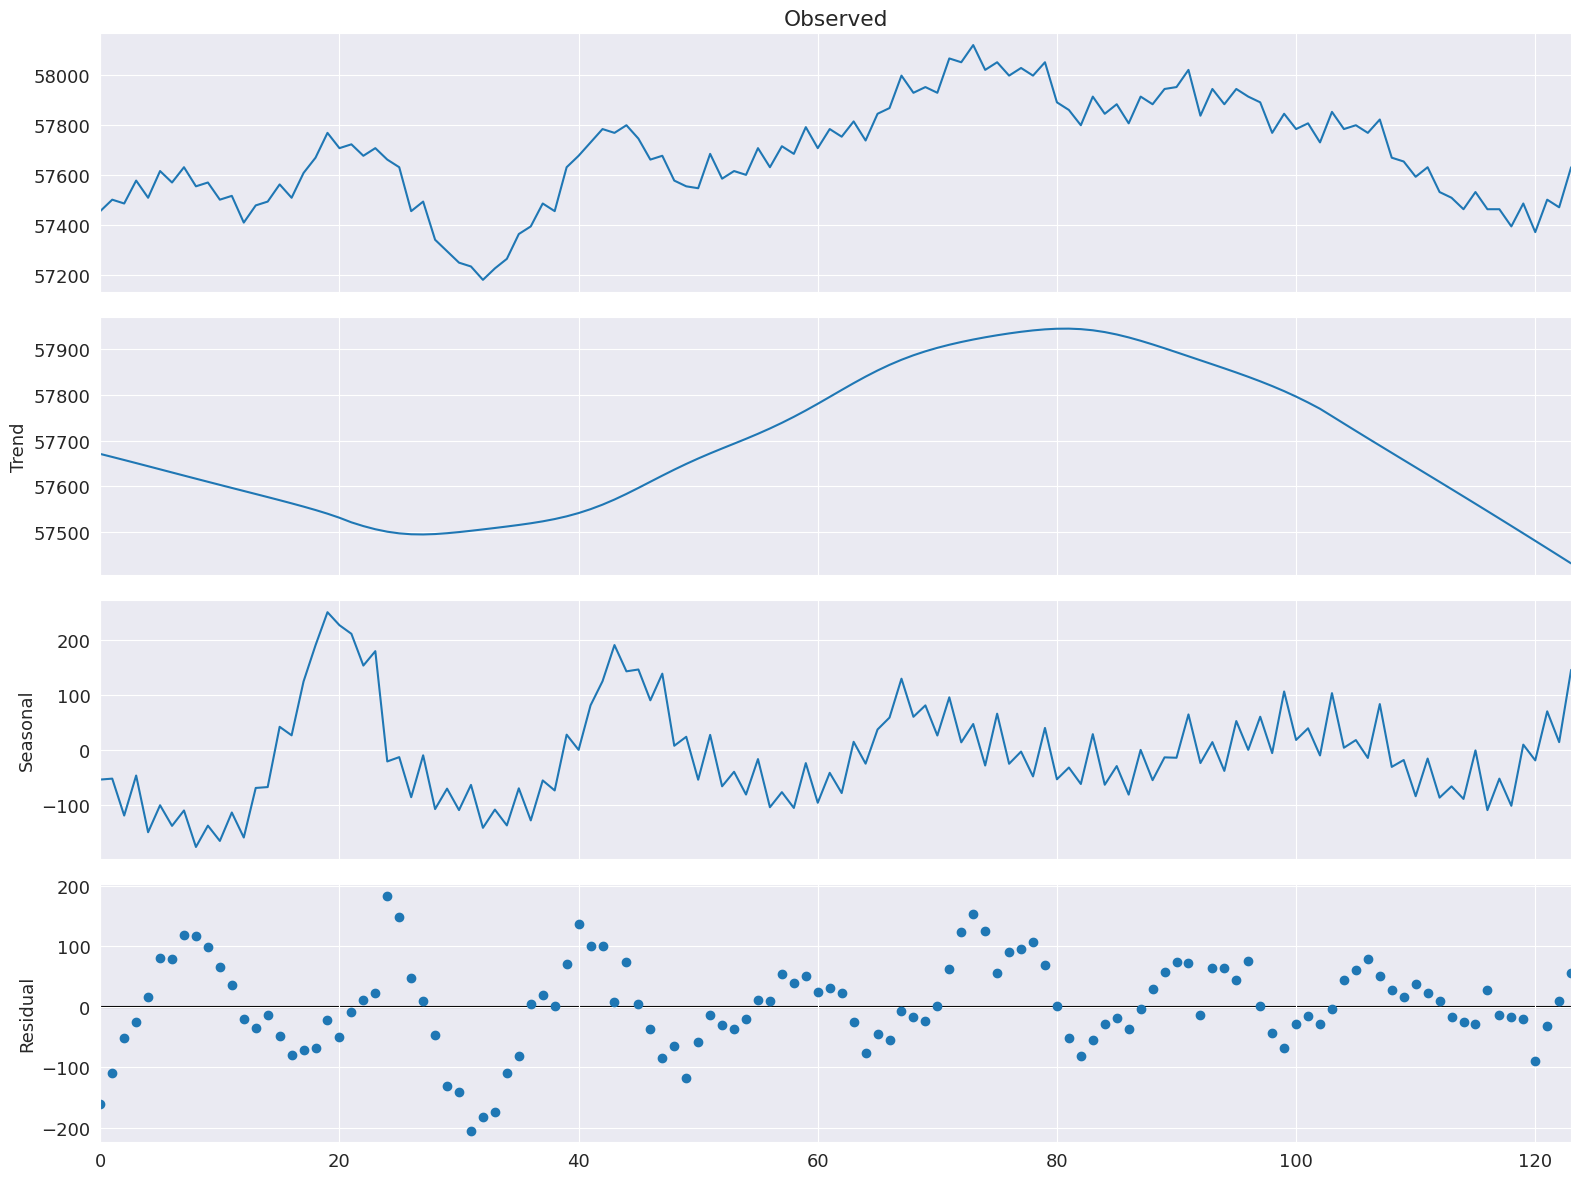

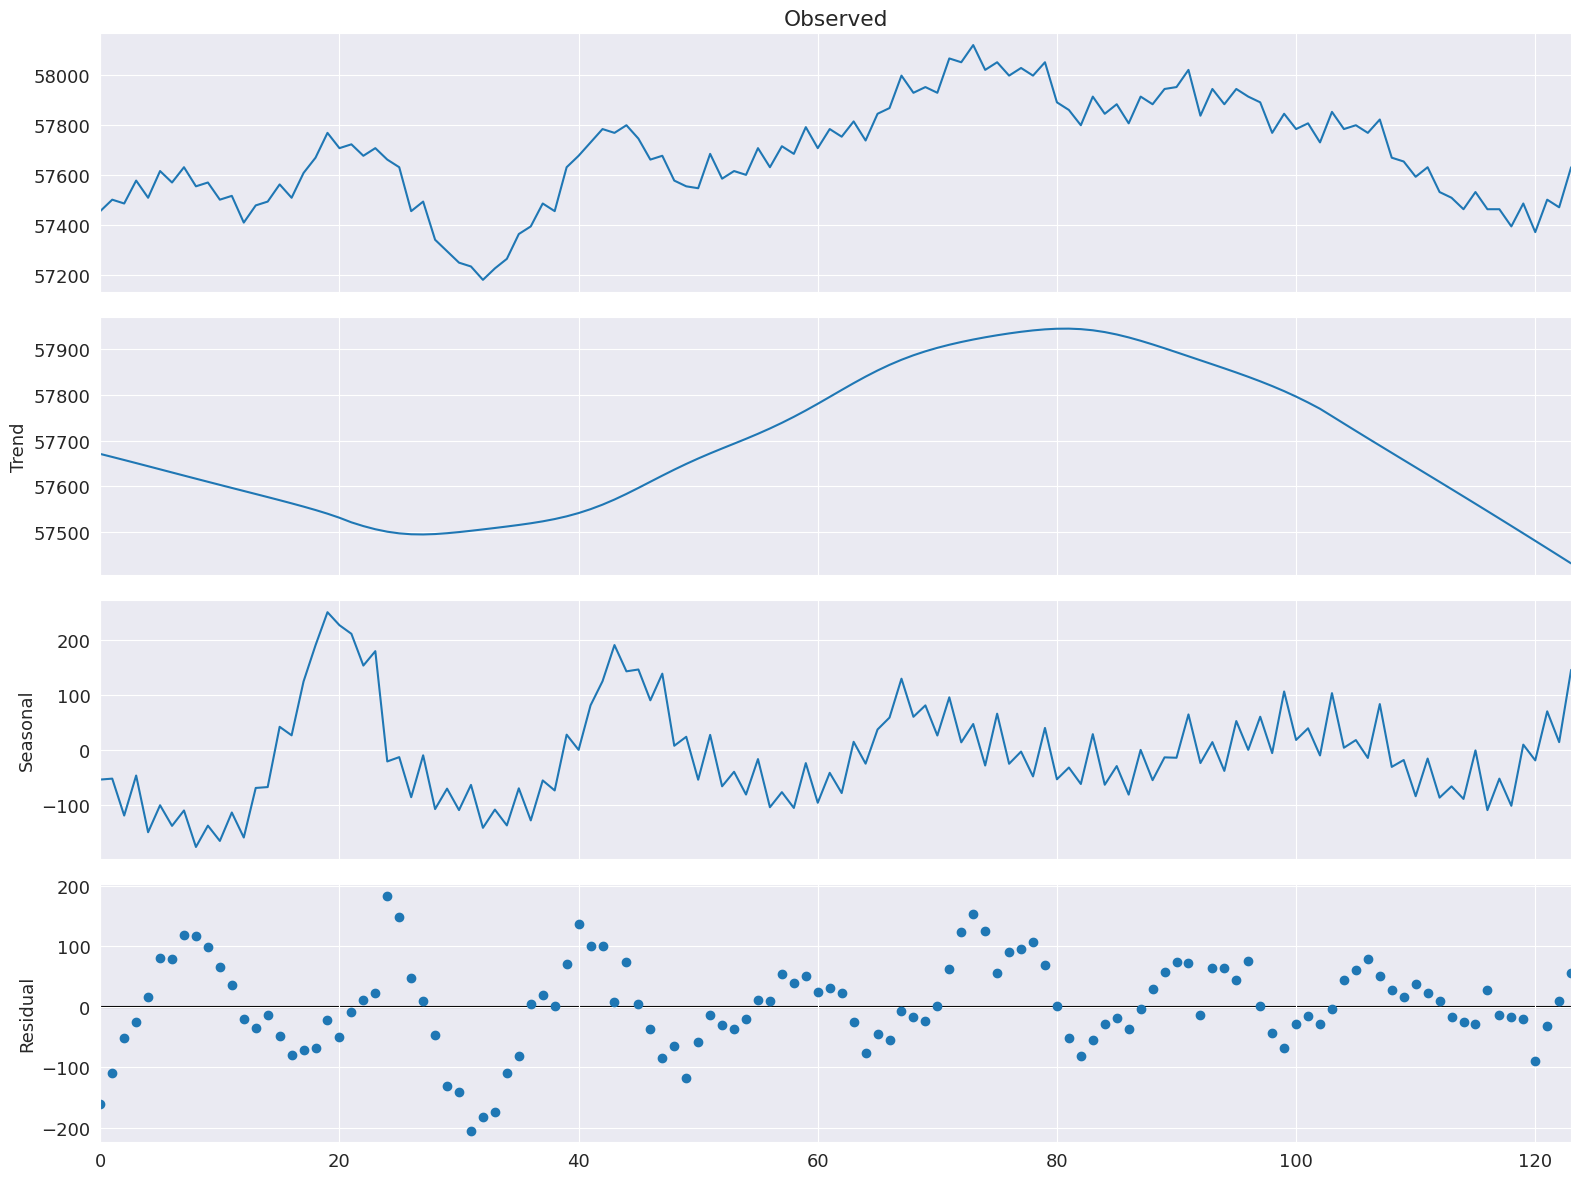

In [7]:
detrend_point_best = MSTL(point_best, periods=[24, 24 * 5])
residual_point_best = detrend_point_best.fit()
residual_point_best.plot()

In [8]:
residual_point_best.resid.shape

(124,)

<xarray.DataArray 'z' (lat: 32, lon: 64, time: 124)> Size: 2MB
array([[[ 1.67453068e+02,  1.41035008e+02,  1.33605069e+02, ...,
          2.26575514e+02,  1.35469118e+02,  1.70632894e+01],
        [ 1.83829498e+02,  1.55258209e+02,  1.40841871e+02, ...,
          2.14459423e+02,  1.30792293e+02,  1.60864706e+01],
        [ 2.00649552e+02,  1.69439010e+02,  1.48056702e+02, ...,
          2.04600384e+02,  1.29379260e+02,  1.07382722e+01],
        ...,
        [ 1.24075559e+02,  1.00430404e+02,  1.14129483e+02, ...,
          2.48530314e+02,  1.54419525e+02,  4.97477171e+01],
        [ 1.34268700e+02,  1.10593130e+02,  1.22595082e+02, ...,
          2.44296585e+02,  1.47178809e+02,  3.53204532e+01],
        [ 1.50503995e+02,  1.26046339e+02,  1.28910517e+02, ...,
          2.35779472e+02,  1.40990154e+02,  2.49495502e+01]],

       [[ 6.59858371e+01,  4.45912170e+01,  3.00886559e+01, ...,
         -8.00103207e+00, -2.00999471e+02, -3.21925432e+02],
        [ 9.78607385e+01,  6.45696046e+0

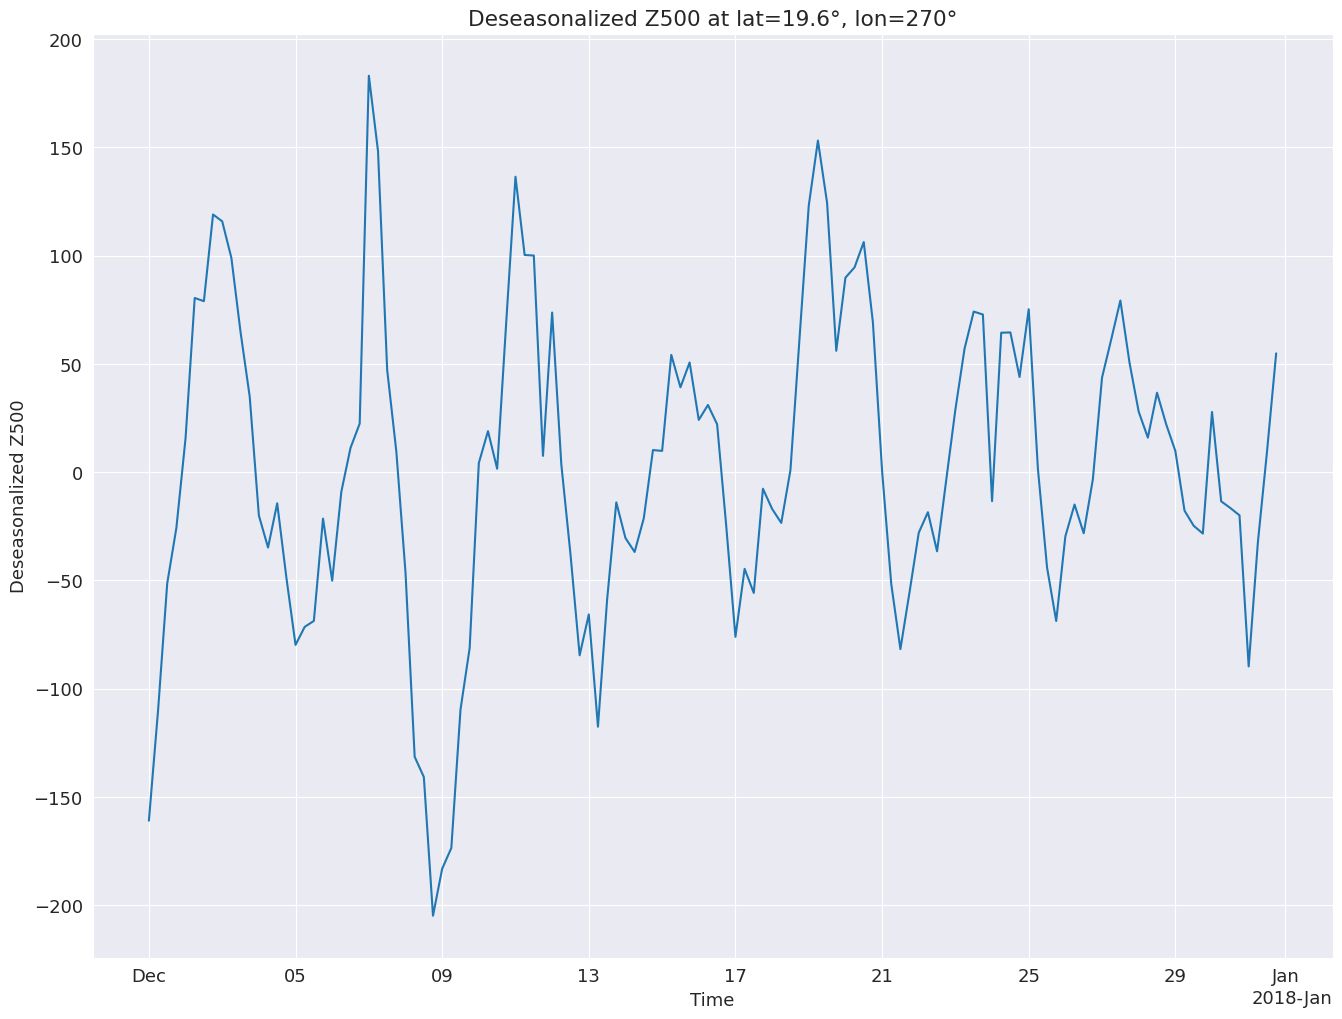

In [9]:
def mstl_detrend(ts, periods):
    """
    Apply MSTL decomposition to a 1D numpy array and return the residuals.
    
    Parameters
    ----------
    ts : array_like
        Time series data.
    period : array_like
        Enter multiple seasonal period you suspect in an array form. For 
        instance, if we suspect daily and weekly periodicity, we enter 
        period = [24, 24*5]
    
    Returns
    -------
    detrended_ts : numpy array
        The residual time series after removing the seasonal component.
    """
    detrend = MSTL(ts, periods=periods).fit()
    return detrend.resid

periods = [24, 24*5]

residuals = xr.apply_ufunc(
    mstl_detrend,       
    data['z'].load(),                 
    input_core_dims=[['time']],  
    output_core_dims=[['time']],
    kwargs={'periods': periods},   
    vectorize=True,    
)

# residuals for GP regression.
print(residuals)

# Plot an example time series from a specific grid point
example_ts = residuals.sel(lat=19.6, lon=270, method='nearest')
example_ts.plot.line()
plt.xlabel('Time')
plt.ylabel('Deseasonalized Z500')
plt.title('Deseasonalized Z500 at lat=19.6°, lon=270°')
plt.show()